Wymyślone "z głowy" rzuty monetą z wykładu z Ekonometrii finansowej (fake) oraz 1000 ciągów rzutów monetą wygenerowanych z generatora liczb pseudolosowych:

[https://docs.google.com/spreadsheets/d/1eI8uGEHNUZptv2wbNQdXLQTwQndGUstGFmtZ4VWNqWY/edit?usp=sharing]

Wciągamy dane:

In [2]:
import pandas as pd
URLCSV = "https://docs.google.com/spreadsheets/d/1eI8uGEHNUZptv2wbNQdXLQTwQndGUstGFmtZ4VWNqWY/export?format=csv"
dane = pd.read_csv(URLCSV)
print(dane.head())

   LP                                              rzuty  fake  score  \
0   1  OOOOROORRRRRRORORORROOOORORRRRORROOOROORRRROOO...     1    565   
1   2  OOROOORRORRROOROROORROROOOORORROOORRORRROROORO...     1    408   
2   3  ORORORORRORORORORRORORRROOOROOROOOORRRROOROORO...     1    513   
3   4  OORORROOORRROOORROOOORRROOORRORROORRORRORRORRR...     1    333   
4   5  OORORRROROROOORRORRORROOORORROOORORORROORROOOR...     1     88   

   pierwszy_O  liczba_serii  liczba_O  max_seria  runtest_z      sd10  \
0           1            49        49          6  -0.297627  0.128668   
1           1            57        53          5   1.145949  0.082327   
2           1            56        52          9   0.922152  0.139841   
3           1            53        49          4   0.305671  0.087560   
4           1            64        48          3   2.532898  0.078881   

   sum_2max  sum_3max  sum_4max  sum_5max  sum_6max  sum_7max  count_1  
0        11        15        19        23        

In [4]:
import pandas as pd

tab = pd.crosstab(dane['fake'], dane['pierwszy_O'])
print(tab)

pierwszy_O    0    1
fake                
0           508  492
1             7   23


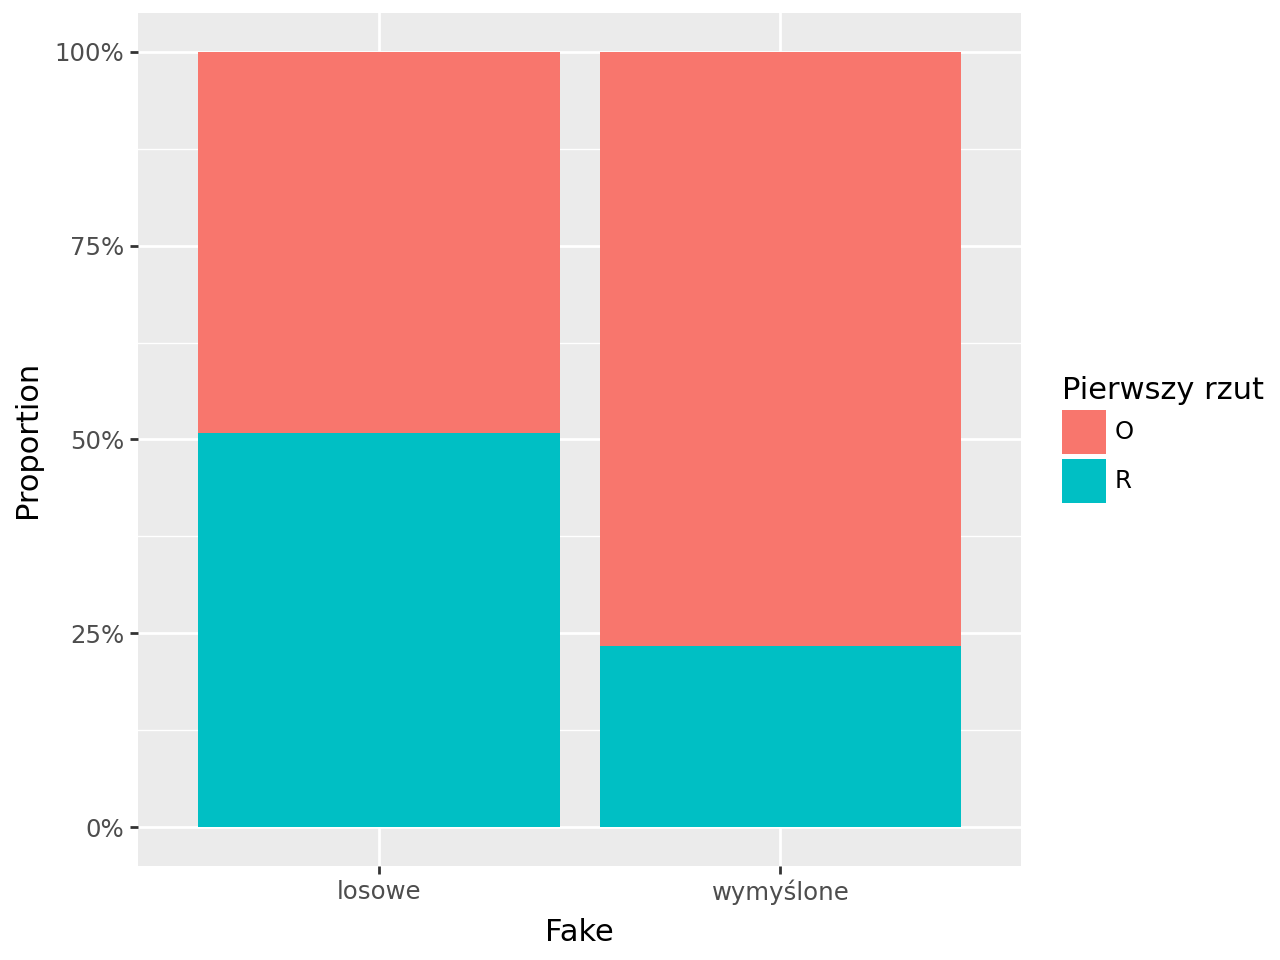

In [11]:
from plotnine import *
dane['fake2'] = dane['fake'].astype(str)
dane.loc[dane['fake'] == 1, 'fake2'] = "wymyślone"
dane.loc[dane['fake'] == 0, 'fake2'] = "losowe"
dane['pierwszy_rzut'] = dane['pierwszy_O'].astype(str)
dane.loc[dane['pierwszy_O'] == 1, 'pierwszy_rzut'] = "O"
dane.loc[dane['pierwszy_O'] == 0, 'pierwszy_rzut'] = "R"

(
    ggplot(dane, aes(x='fake2', fill='pierwszy_rzut'))
    + geom_bar(position='fill')  # 100% stacked automatically
    + scale_y_continuous(labels=lambda l: ["{:.0%}".format(v) for v in l])
    + labs(x='Fake', y='Proportion', fill='Pierwszy rzut')
)

In [12]:
import scipy.stats as stats

test_chi2 = stats.chi2_contingency(tab)
test_chi2

Chi2ContingencyResult(statistic=np.float64(7.725), pvalue=np.float64(0.00544613598903063), dof=1, expected_freq=array([[500., 500.],
       [ 15.,  15.]]))

In [19]:
observed = dane['pierwszy_O'][dane['fake']==1].value_counts().tolist()
print(observed)
total = sum(observed)
expected = [total * 0.5, total * 0.5]
print(expected)

stats.chisquare(f_obs=observed, f_exp=expected)


[23, 7]
[15.0, 15.0]


Power_divergenceResult(statistic=np.float64(8.533333333333333), pvalue=np.float64(0.0034870048921413857))